In [1]:
import torch
import transformers
from model.language_model.mistral import MistralForCausalLM
from model.language_model.llama import LlamaForCausalLM, LlamaTokenizer
from model.language_model.qwen2 import Qwen2ForCausalLM, Qwen2Tokenizer
from PIL import Image
import os
import json
import re

/research/chengruogu/anaconda3/envs/bunny/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set device
torch.set_default_device('cuda:0')  # or 'cuda'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

model_name = '01-ai/Yi-1.5-34B-Chat'
# device_map='auto'
model = LlamaForCausalLM.from_pretrained(model_name, torch_dtype='auto')

# model = MistralForCausalLM.from_pretrained('WizardLM/WizardMath-7B-V1.1')
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

ValueError: `rope_scaling` must be a dictionary with two fields, `type` and `factor`, got {'factor': 8.0, 'low_freq_factor': 1.0, 'high_freq_factor': 4.0, 'original_max_position_embeddings': 8192, 'rope_type': 'llama3'}

In [3]:
with open('/research/zhangzr/Bunny/data/gllava-data/qa_tuning.json', 'r') as f:
    qa_data = json.load(f)

In [4]:
idx = 0
gllava_data_item = qa_data[idx]
image_path = gllava_data_item['image']
raw_qs = gllava_data_item['conversations'][0]['value']
solution = gllava_data_item['conversations'][1]['value']

# 使用正则表达式来匹配
pattern = r'Question: (.*?)\nChoices'
match = re.search(pattern, raw_qs)

if match:
    qs = match.group(1).strip()
    # print(f'qs: {qs}')
else:
    print("No match found")
    
    
# 使用正则表达式匹配 "Answer:" 后的选项
match = re.search(r'Answer:\s*([A-Z])', solution)

if match:
    answer = match.group(1)
    print(f"The answer is option {answer}.")
else:
    print("Answer not found.")

The answer is option C.


In [6]:
prompt = f'Suppose you are a clever student; the following is a geometry question and its solution:\nQuestion: {qs}\nSolution: {solution}\nBased on this solution, organize the reasoning steps into Step 1, Step 2, etc., step by step. Be sure to exclude information about the options in the solution.'
# prompt = f'Suppose you are a clever student; the following is a geometry question and its solution:\nQuestion: {qs}\nSolution: {ans}\nBased on this solution, organize the reasoning steps into Step 1, Step 2, etc., step by step. Finally select the right choices or option in the following format: Answer: [A-D].'
print(f'prompt is:\n{prompt}')
messages = [
    {"role": "user", "content": prompt},
]

formalized_prompt = tokenizer.apply_chat_template(conversation=messages, tokenize=False, add_generation_prompt=True)
# formalized_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n你是谁？<|im_end|>\n<|im_start|>assistant\n我是chatgpt<|im_end|><|im_start|>user\n你是chatgpt还是qwen<|im_end|>\n<|im_start|>assistant\n"
print(f"formalized_prompt is:\n{[formalized_prompt]}")
input_ids = torch.tensor(tokenizer(formalized_prompt).input_ids, dtype=torch.long).unsqueeze(0)

prompt is:
Suppose you are a clever student; the following is a geometry question and its solution:
Question: In the given diagram, if angle 1 has a measure of 35.0 degrees, what is the measure of angle 2?
Solution: Since angle 1 + angle 2 = 180°, and angle 1 = 35°, therefore angle 2 = 145°. Therefore, option C is selected.
Answer:C
Based on this solution, organize the reasoning steps into Step 1, Step 2, etc., step by step. Be sure to exclude information about the options in the solution.
formalized_prompt is:
['<|im_start|>user\nSuppose you are a clever student; the following is a geometry question and its solution:\nQuestion: In the given diagram, if angle 1 has a measure of 35.0 degrees, what is the measure of angle 2?\nSolution: Since angle 1 + angle 2 = 180°, and angle 1 = 35°, therefore angle 2 = 145°. Therefore, option C is selected.\nAnswer:C\nBased on this solution, organize the reasoning steps into Step 1, Step 2, etc., step by step. Be sure to exclude information about the 

Question: In the given diagram, if angle 1 has a measure of 35.0 degrees, what is the measure of angle 2?
Respones is:
Step 1: Identify the relationship between angle 1 and angle 2. In the given diagram, angle 1 and angle 2 are supplementary angles, which means they add up to 180 degrees.

Step 2: Determine the measure of angle 1. According to the question, angle 1 has a measure of 35.0 degrees.

Step 3: Use the relationship between angle 1 and angle 2 to find the measure of angle 2. Since angle 1 and angle 2 are supplementary angles, we can write the equation: angle 1 + angle 2 = 180°.

Step 4: Substitute the known value of angle 1 (35°) into the equation: 35° + angle 2 = 180°.

Step 5: Solve for angle 2 by subtracting the measure of angle 1 from 180°: angle 2 = 180° - 35°.

Step 6: Calculate the measure of angle 2: angle 2 = 145°.

Step 7: Conclude that the measure of angle 2 is 145 degrees.


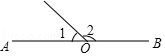

In [7]:
# generate
output_ids = model.generate(
    input_ids,
    max_new_tokens=500,
    eos_token_id=tokenizer.eos_token_id,
    use_cache=False)[0]

respones = tokenizer.decode(output_ids[input_ids.shape[1]:], skip_special_tokens=True)
print(f'Question: {qs}')
print(f'Respones is:\n{respones}')
image = Image.open(os.path.join('/research/zhangzr/Bunny/data/gllava-data/images', image_path)).show()